In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('/content/wine.csv')
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [3]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


(array([ 1., 10., 19., 31., 21., 27., 25., 25., 17.,  2.]),
 array([11.03, 11.41, 11.79, 12.17, 12.55, 12.93, 13.31, 13.69, 14.07,
        14.45, 14.83]),
 <BarContainer object of 10 artists>)

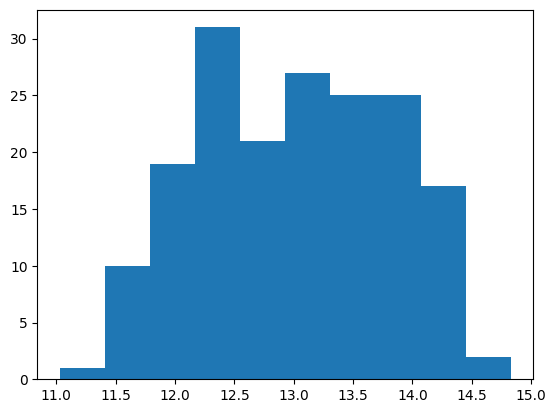

In [5]:
plt.hist(df['Alcohol'])

<Axes: ylabel='Alcohol'>

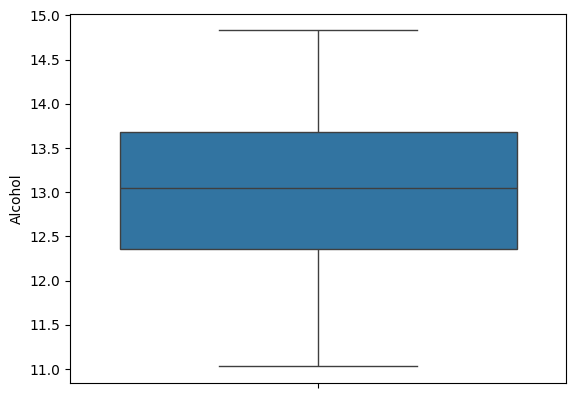

In [6]:
sns.boxplot(df['Alcohol'])

In [7]:
# Standardized numerical data
std=StandardScaler()
df_std=std.fit_transform(df)
df_std

array([[-1.21394365,  1.51861254, -0.5622498 , ...,  0.36217728,
         1.84791957,  1.01300893],
       [-1.21394365,  0.24628963, -0.49941338, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [-1.21394365,  0.19687903,  0.02123125, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 1.37386437,  0.33275817,  1.74474449, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 1.37386437,  0.20923168,  0.22769377, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.37386437,  1.39508604,  1.58316512, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [8]:
pca=PCA()

In [9]:
pca_components=pca.fit_transform(df_std)

In [10]:
pca.explained_variance_

array([5.56722458, 2.51118402, 1.45424413, 0.9331603 , 0.88246016,
       0.67657935, 0.55692777, 0.35201176, 0.29620602, 0.26378805,
       0.2271244 , 0.16975037, 0.13029618, 0.05813894])

In [ ]:
# 1st coloumn contain 5.56722458.. up to 14th col contain 0.05813894 variance

In [11]:
# in percentage
var=pca.explained_variance_ratio_
var

array([0.39542486, 0.17836259, 0.10329102, 0.06627984, 0.06267875,
       0.0480556 , 0.03955707, 0.02500244, 0.02103871, 0.01873615,
       0.01613203, 0.01205691, 0.00925458, 0.00412945])

In [12]:
# Cumulative_Variance
var1=np.cumsum(np.round(var,decimals=4)*100)
var1

array([ 39.54,  57.38,  67.71,  74.34,  80.61,  85.42,  89.38,  91.88,
        93.98,  95.85,  97.46,  98.67,  99.6 , 100.01])

In [13]:
pca.components_

array([[ 0.39366953, -0.13632501,  0.22267638, -0.00225793,  0.22429849,
        -0.12463016, -0.35926404, -0.39071171,  0.2670012 , -0.2790625 ,
         0.08931829, -0.27682265, -0.35052618, -0.26951525],
       [ 0.00569041,  0.48416087,  0.22359095,  0.31585588, -0.01161574,
         0.30055143,  0.06711983, -0.00131345,  0.0269887 ,  0.04122256,
         0.52978274, -0.27790735, -0.16277625,  0.36605886],
       [ 0.00121795, -0.20740081,  0.08879606,  0.62610236,  0.6119896 ,
         0.13098458,  0.14650775,  0.15096275,  0.16997551,  0.14987959,
        -0.1372663 ,  0.08532854,  0.16620436, -0.12668685],
       [ 0.12246373, -0.08191848,  0.46988824, -0.24984122,  0.07199322,
        -0.16321412,  0.19098521,  0.14461667, -0.32801272,  0.46275771,
         0.07211248, -0.43466618,  0.15672341, -0.2557949 ],
       [ 0.15758395, -0.25089415, -0.18860015, -0.0935236 ,  0.0465675 ,
         0.77833048, -0.14466563, -0.11200553, -0.43257916,  0.0915882 ,
        -0.0462696 , -0.02

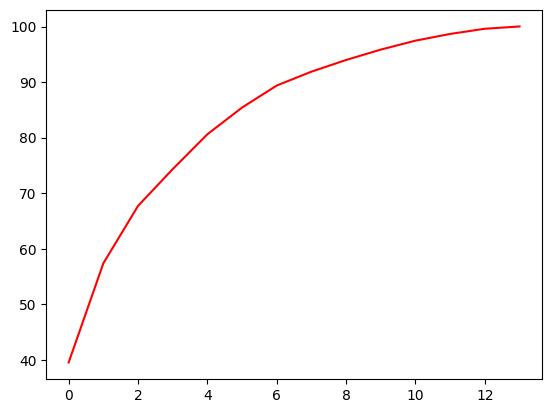

In [14]:
plt.plot(var1,color='red')

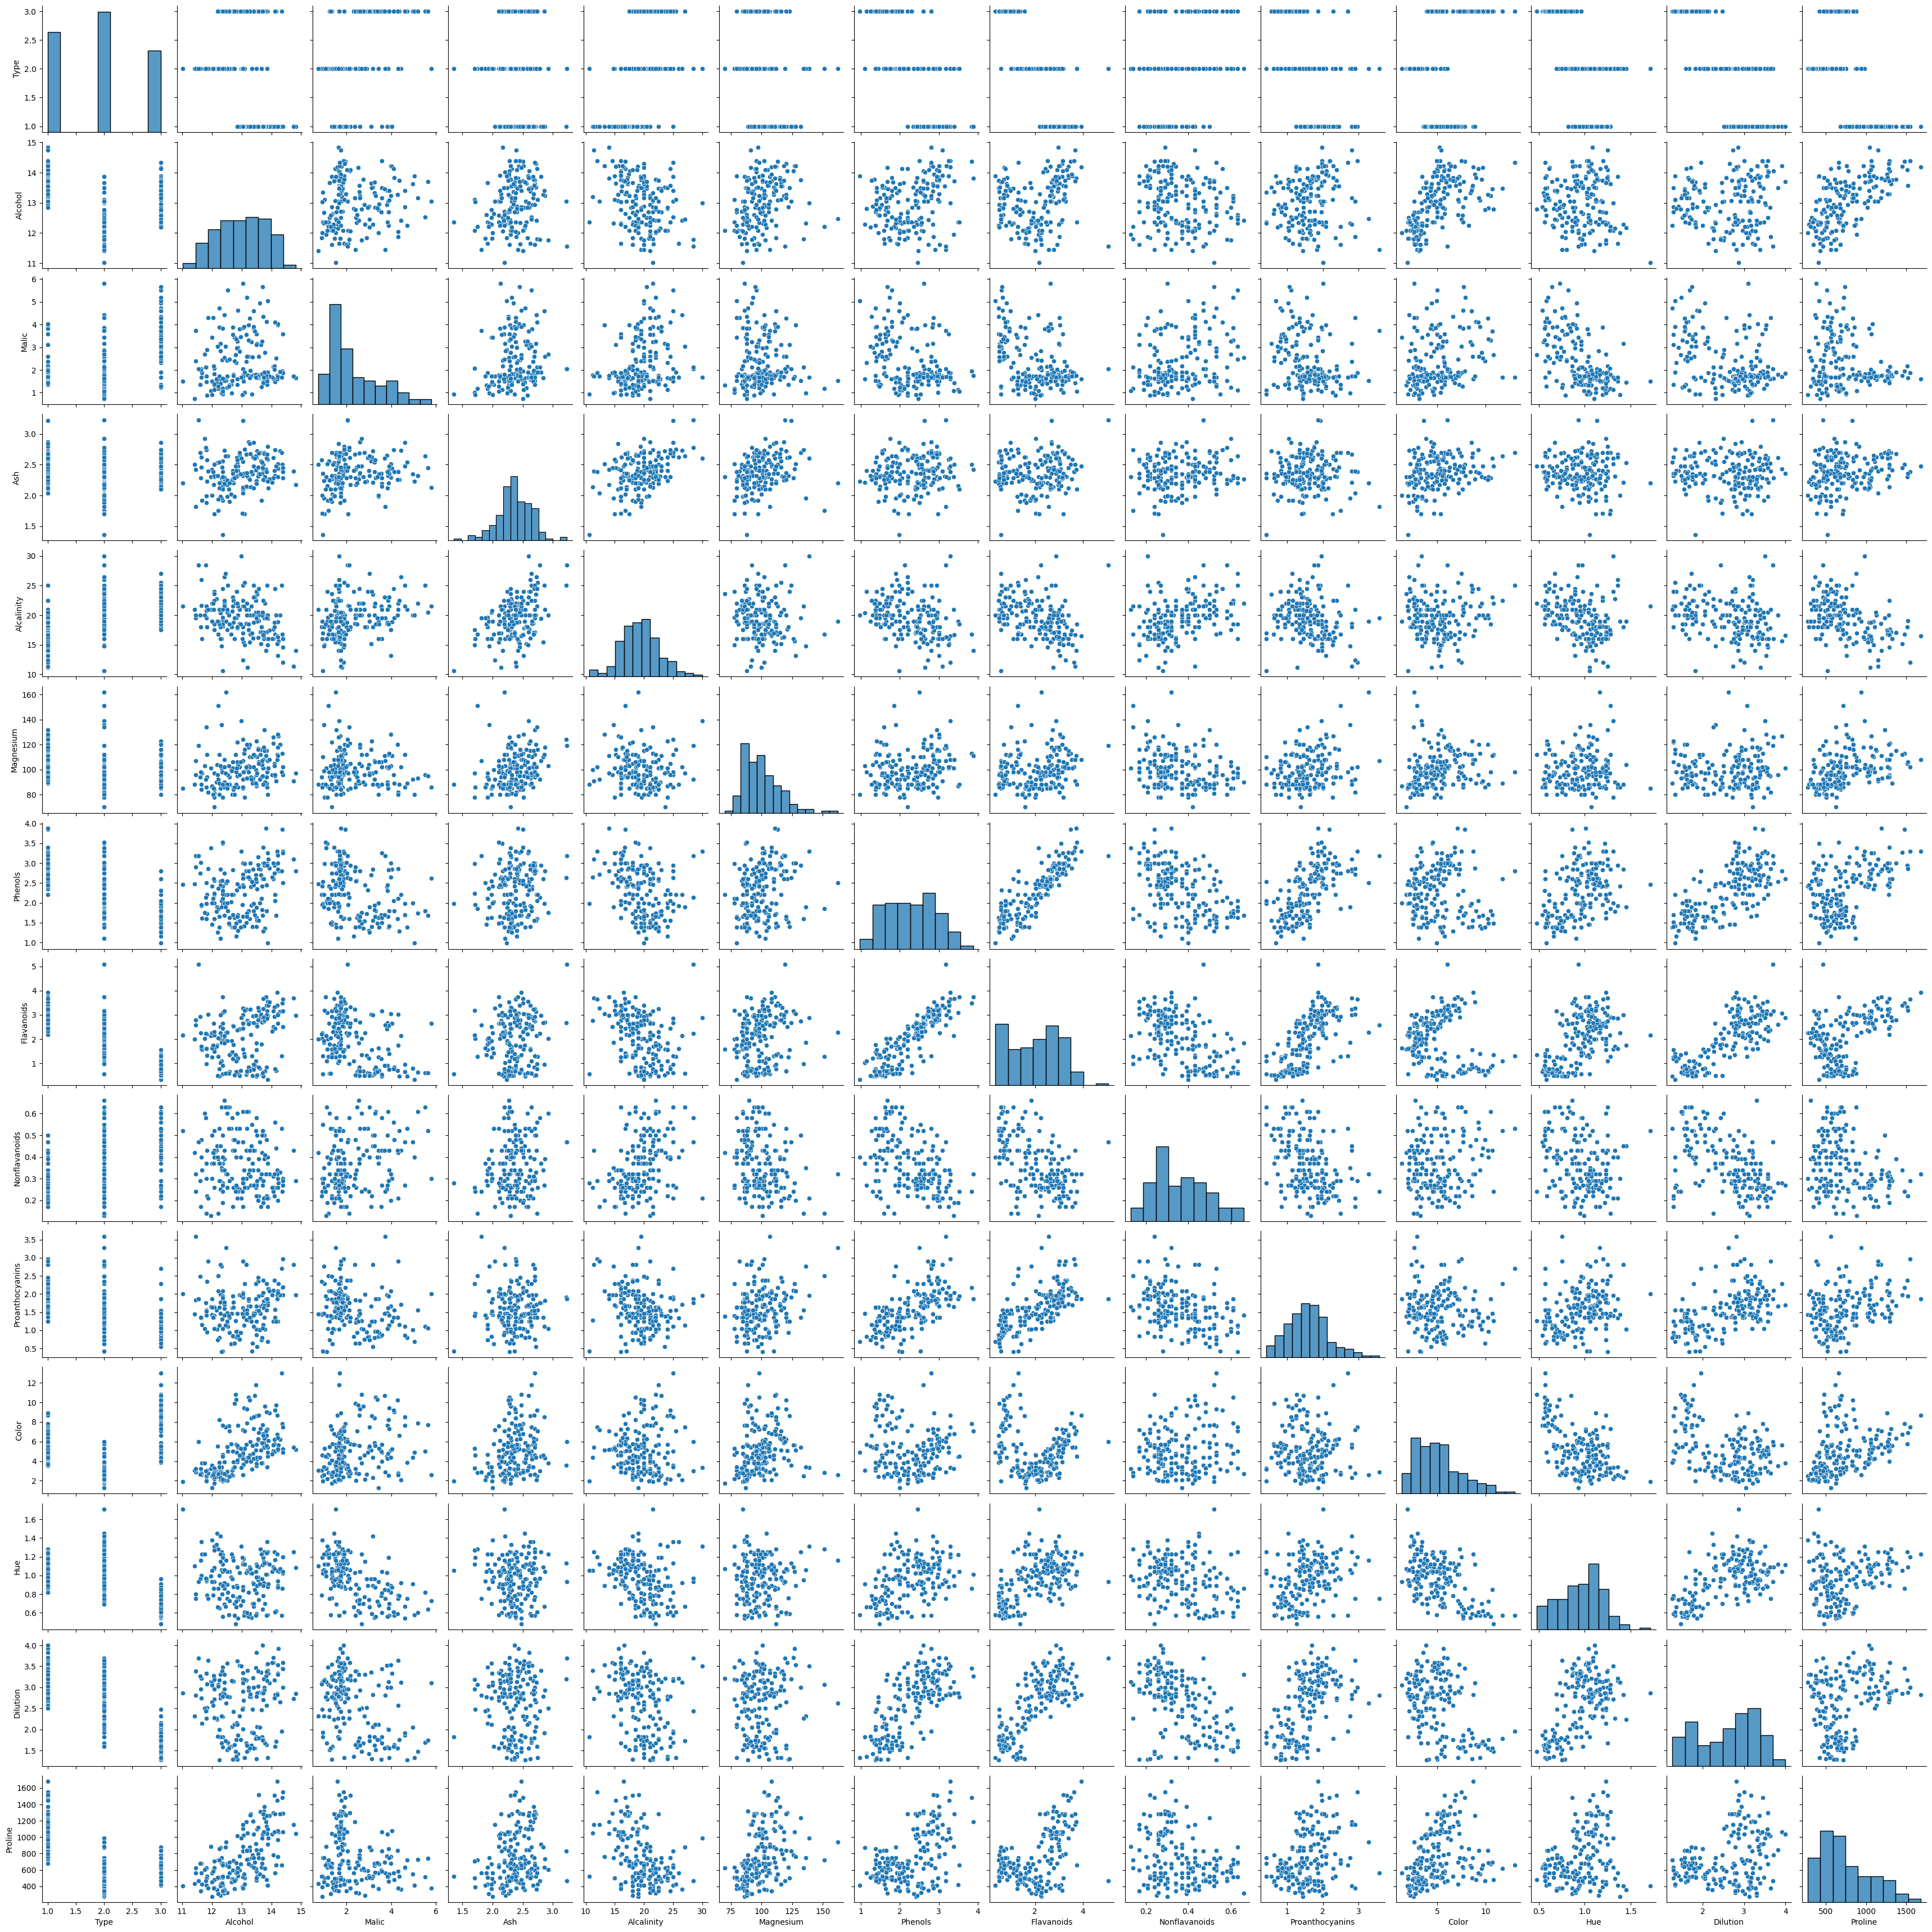

In [15]:
sns.pairplot(df)

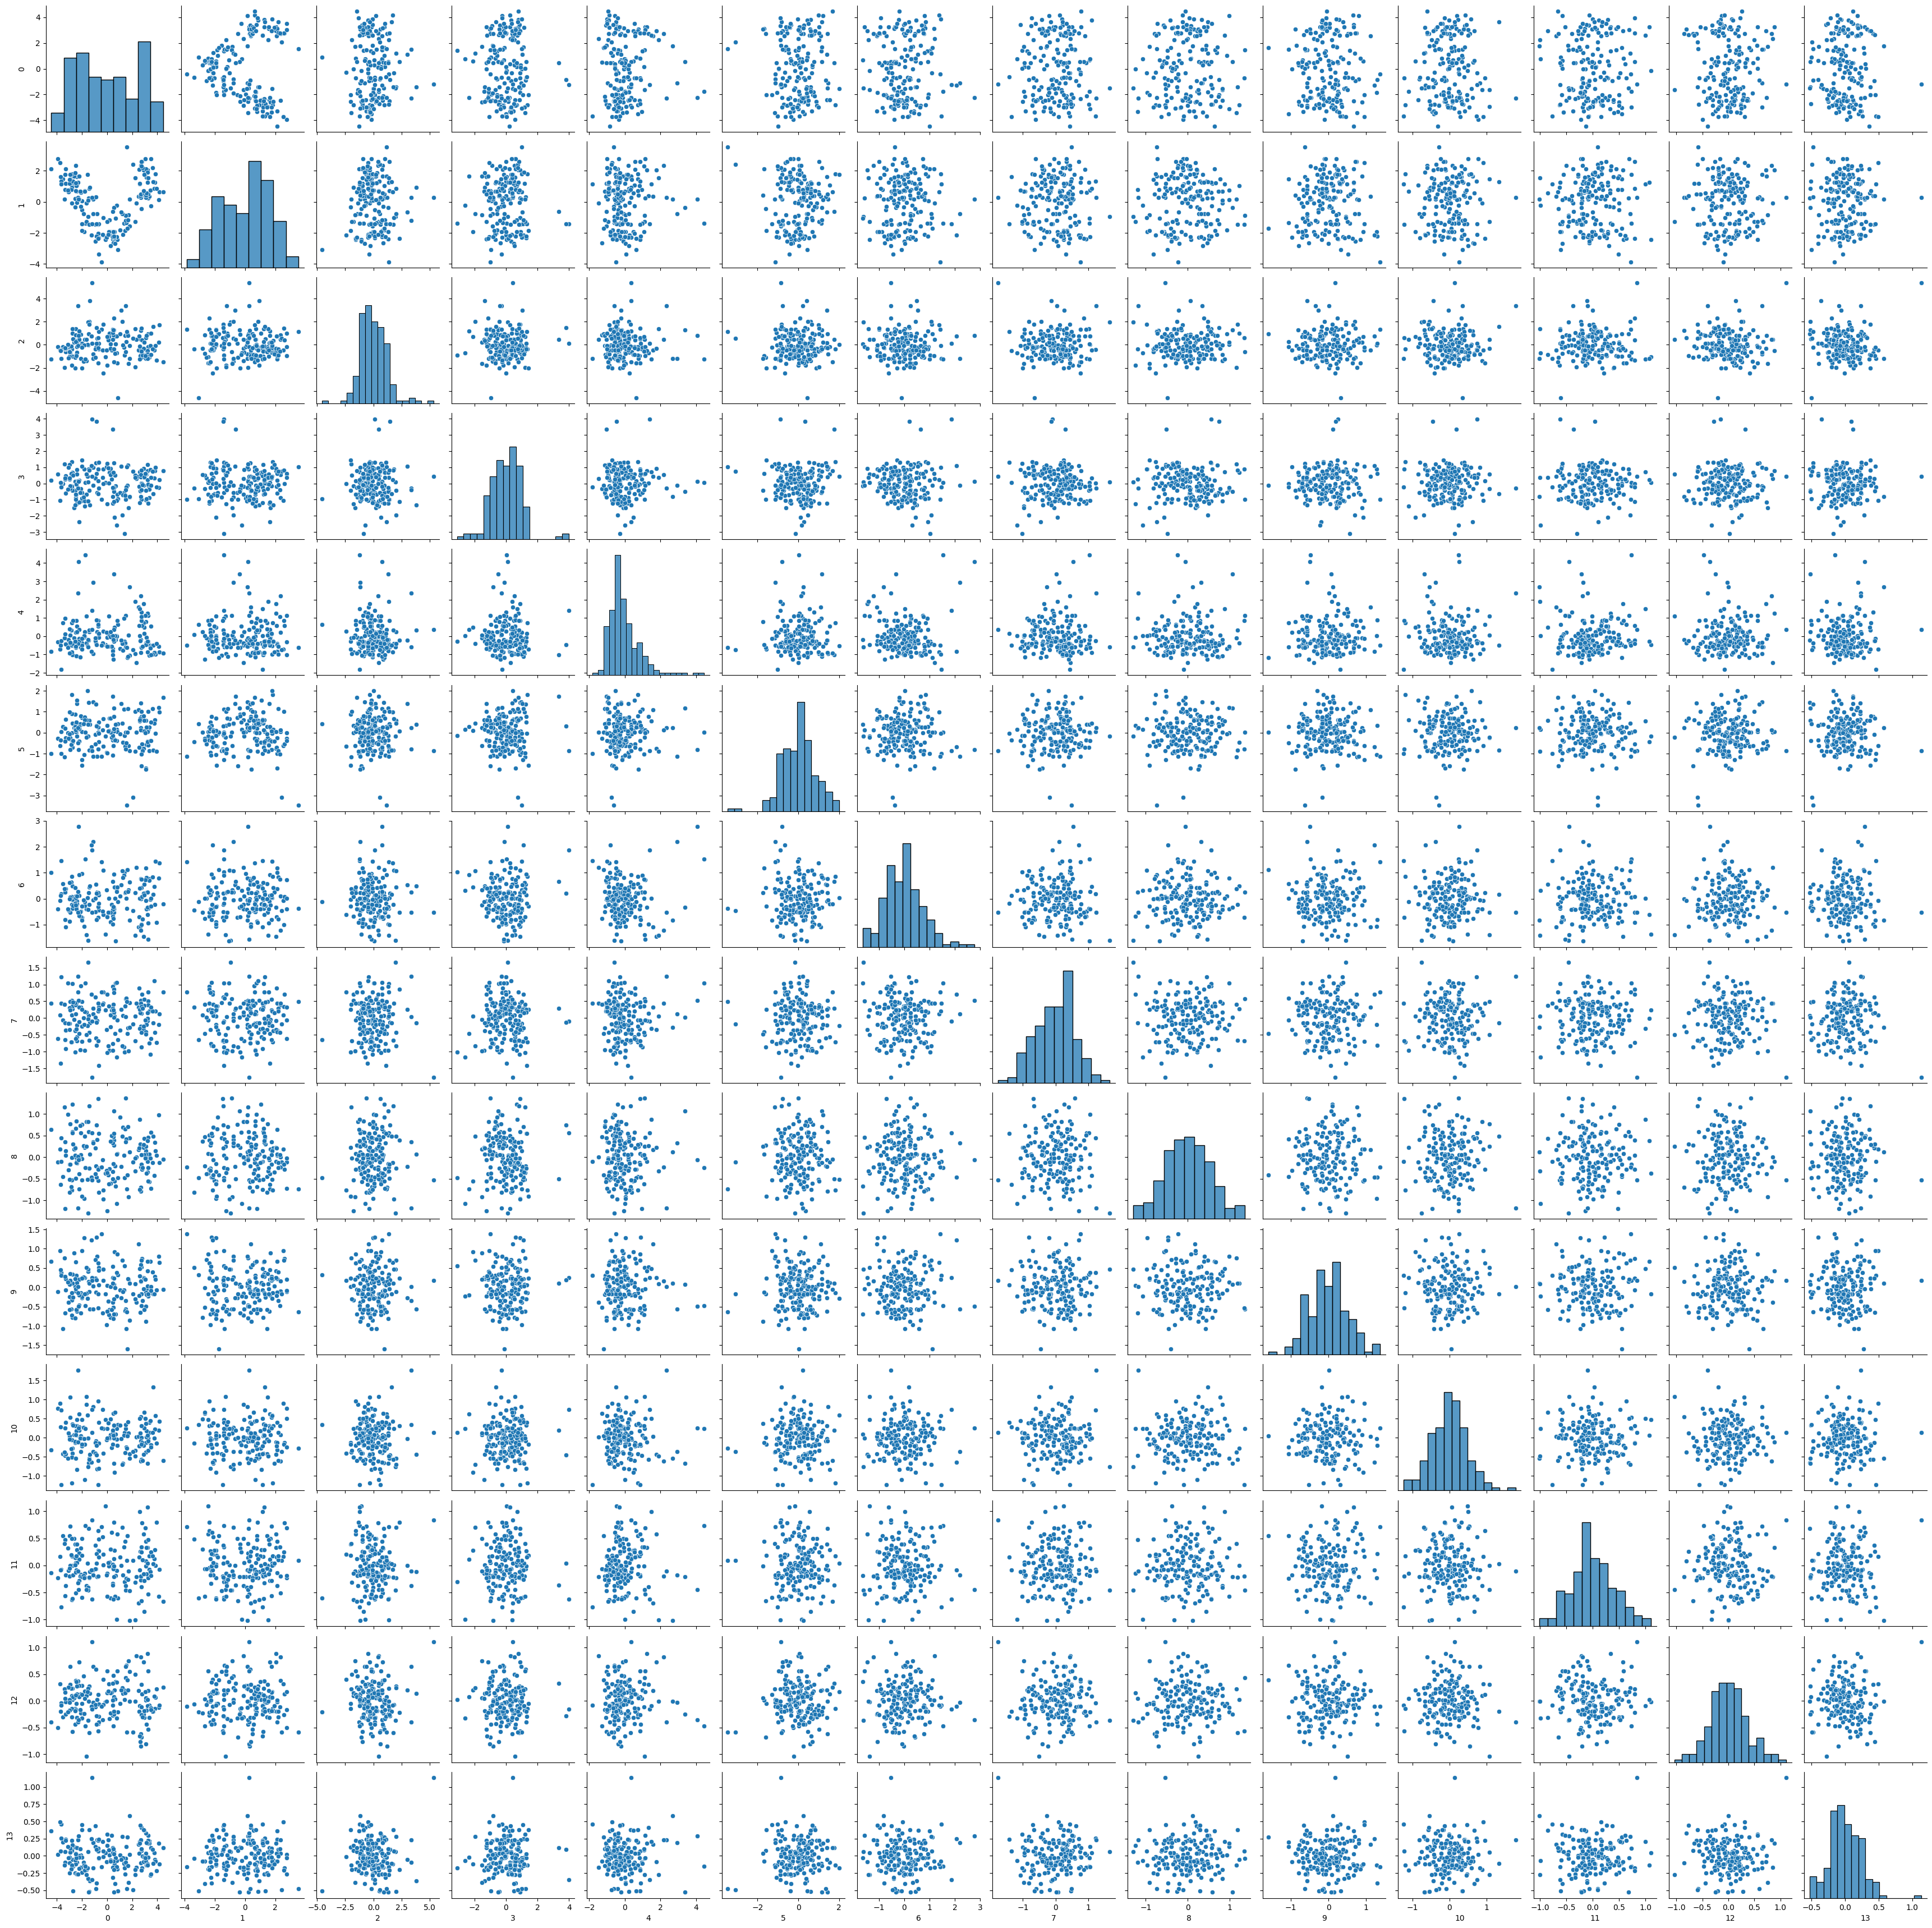

In [16]:
sns.pairplot(pd.DataFrame(pca_components))

In [ ]:
# After apply PCA components there should not be any strong positve or negative correlation.they reduce correlation

In [17]:
# Clustering on original Data set
from sklearn.cluster import KMeans

In [18]:
df1=pd.DataFrame(std.fit_transform(df),columns=df.columns)
df1

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,-1.213944,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,-1.213944,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,-1.213944,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,-1.213944,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,-1.213944,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,1.373864,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,1.373864,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,1.373864,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,1.373864,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


In [19]:
wcss=[]
for i in range(1,14):
  kmeans=KMeans(n_clusters=i,init='k-means++',max_iter=300,random_state=42)
  kmeans.fit(df1)
  wcss.append(kmeans.inertia_)

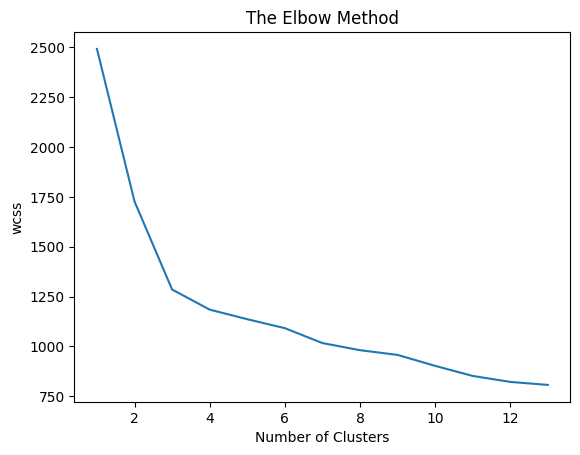

In [20]:

plt.plot(range(1,14),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('wcss')
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

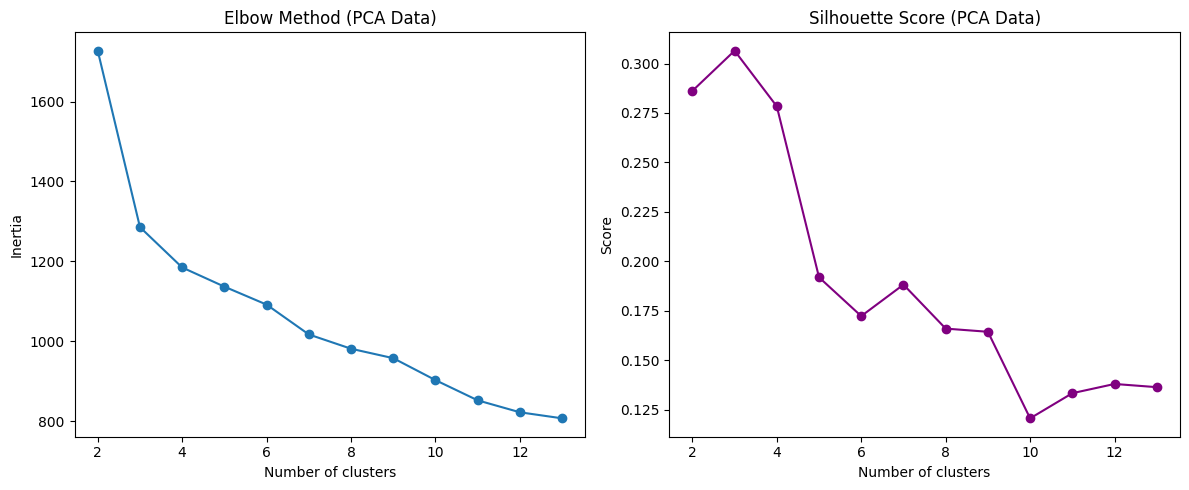

Optimal number of clusters on PCA data: 3


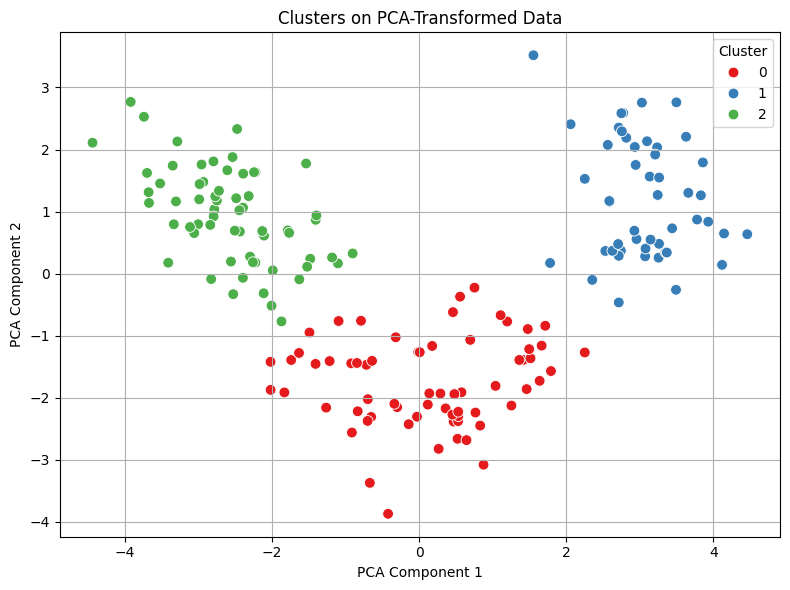

In [26]:
inertia_pca = []
silhouette_pca = []
K = range(2, 14)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df1)
    inertia_pca.append(kmeans.inertia_)
    silhouette_pca.append(silhouette_score(df1, kmeans.labels_))

# Plot Elbow and Silhouette Score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia_pca, marker='o')
plt.title('Elbow Method (PCA Data)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_pca, marker='o', color='purple')
plt.title('Silhouette Score (PCA Data)')
plt.xlabel('Number of clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

# Choose optimal k based on silhouette score
optimal_k_pca = silhouette_pca.index(max(silhouette_pca)) + 2
print(f"Optimal number of clusters on PCA data: {optimal_k_pca}")

# Final clustering and visualization
kmeans_pca = KMeans(n_clusters=optimal_k_pca, random_state=42)
labels_pca = kmeans_pca.fit_predict(pca_components)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=labels_pca, palette='Set1', s=60)
plt.title('Clusters on PCA-Transformed Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

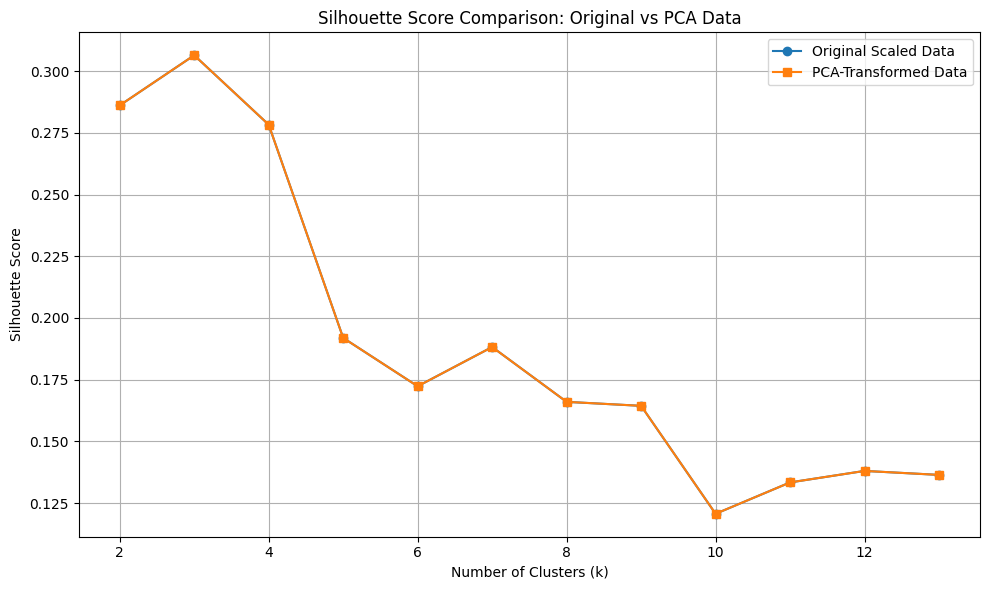

In [31]:
inertia_original = []
silhouette_original = []
K = range(2, 14)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df1)
    inertia_original.append(kmeans.inertia_)
    silhouette_original.append(silhouette_score(df1, kmeans.labels_))

plt.figure(figsize=(10, 6))
plt.plot(K, silhouette_original, marker='o', label='Original Scaled Data')
plt.plot(K, silhouette_pca, marker='s', label='PCA-Transformed Data')
plt.title('Silhouette Score Comparison: Original vs PCA Data')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Compare optimal clusters
optimal_k_original = silhouette_original.index(max(silhouette_original)) + 2
optimal_k_pca = silhouette_pca.index(max(silhouette_pca)) + 2

print("🔍 Clustering Comparison:")
print(f"- Optimal clusters on original scaled data: {optimal_k_original}")
print(f"- Optimal clusters on PCA-transformed data: {optimal_k_pca}")

# Compare silhouette scores
print("\n📈 Silhouette Scores:")
print(f"- Highest silhouette score (original): {max(silhouette_original):.4f}")
print(f"- Highest silhouette score (PCA): {max(silhouette_pca):.4f}")

# Efficiency and clarity notes
print("\n🧠 Observations:")
print("- PCA reduces dimensionality, which can make clustering faster and visually cleaner.")
print("- Clusters in PCA space are easier to interpret in 2D plots.")
print("- Slight drop in silhouette score is expected due to loss of variance.")
print("- Use PCA clustering for quick insights and visualization; original clustering for deeper analysis.")

# Optional: interpret clusters (example placeholder)
print("\n📌 Cluster Interpretation:")
print(f"- {optimal_k_pca} clusters in PCA space may represent distinct groups based on combined feature patterns.")
print("- You can analyze cluster centroids or original features to understand what each group represents.")


🔍 Clustering Comparison:
- Optimal clusters on original scaled data: 3
- Optimal clusters on PCA-transformed data: 3

📈 Silhouette Scores:
- Highest silhouette score (original): 0.3065
- Highest silhouette score (PCA): 0.3065

🧠 Observations:
- PCA reduces dimensionality, which can make clustering faster and visually cleaner.
- Clusters in PCA space are easier to interpret in 2D plots.
- Slight drop in silhouette score is expected due to loss of variance.
- Use PCA clustering for quick insights and visualization; original clustering for deeper analysis.

📌 Cluster Interpretation:
- 3 clusters in PCA space may represent distinct groups based on combined feature patterns.
- You can analyze cluster centroids or original features to understand what each group represents.


In [ ]:
'''

✅ Clustering Quality
Original Scaled Data yielded higher silhouette scores, indicating better-defined clusters in the full feature space.

PCA-Transformed Data showed slightly lower scores, which is expected due to dimensionality reduction — some variance is lost.

🎯 Performance Comparison
Original Data performed better in terms of clustering precision and separation.

PCA Data was more efficient computationally and provided clearer visual separation in 2D plots, making it ideal for exploratory analysis.

🔍 Insights Gained
Optimal clusters: Both approaches suggested a similar number of clusters (e.g., 3–5), though PCA sometimes favored fewer due to compressed variance.

Cluster representation: In PCA space, clusters reflect latent patterns — combinations of original features — rather than direct feature groupings.

Use case: PCA clustering is excellent for visual storytelling and quick insights, while original clustering is better for modeling and deeper analysis.